## **Shoebill: Protein Crystallization Propensity Predictor**


---


##### **Required Input**

The notebook only requires an AlphaFold-generated ZIP file as input. The required ZIP file can be generated using ColabFold AlphaFold2 with default settings: https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb

##### **Output**
Shoebill will generate:

 - Crystallization probability
 - SHAP analysis plots


---


##### **Note**

The Colab notebook currently supports only one input file at a time. If you need batch processing, please install Shoebill locally and follow the instructions: https://github.com/KJ-Liao/Shoebill/tree/main.

In [1]:
#@title Click `Runtime` -> `Run all` -> upload your `AlphaFold.result.zip` when prompted
# ==================== Setup Environment & Clone Repository ====================
# Clone Shoebill repository
!git clone https://github.com/KJ-Liao/Shoebill.git
%cd Shoebill

# Install Python dependencies
!pip install -q \
    xgboost==3.0.2 \
    shap==0.46.0 \
    biopython \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    joblib \

# Import required libraries
import pandas as pd
import numpy as np
import shap

import os
import re
import requests
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin

import glob
from IPython.display import display, Image

# ==================== Upload & Standardize File Names ====================
print("\nPlease complete the following steps:")
print("\n1. Predict your protein structure using AlphaFold2 or ColabFold")
print("   Recommended notebook:")
print("   https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb")
print("2. Download the AlphaFold output ZIP file")
print("3. Upload the AlphaFold ZIP file\n")

# Import required libraries
from google.colab import files

# Step 1: Upload AlphaFold ZIP
print("Step 1: Upload your AlphaFold result ZIP file")

# Upload AlphaFold ZIP
uploaded_zip = files.upload()
zip_files = [f for f in uploaded_zip if f.lower().endswith(".zip")]
if not zip_files:
    raise FileNotFoundError("No ZIP file detected. Please upload the AlphaFold output ZIP.")

# Extract to Example/AF_Result
input_zip = zip_files[0]
!unzip -o -q "{input_zip}" -d Example/AF_Result

# Step 2: Generate the FASTA file
print("\nStep 2: Generate the FASTA file (TE_Sequence.fasta)")

# Read csv file
sample_name = re.sub(r"(\.result)?(\.results)?\.zip$", "", input_zip, flags=re.IGNORECASE)
sample_name = re.sub(r"[_-]?result[s]?$", "", sample_name, flags=re.IGNORECASE)

folder = Path("Example/AF_Result") / sample_name
csv_files = list(folder.glob("*.csv"))
df = pd.read_csv(csv_files[0])

# Format csv file
name_col = df.columns[0]
seq_col = df.columns[1]

# Generate the FASTA file
output_fasta = "Example/TE_Sequence.fasta"
with open(output_fasta, "w") as f:
    for _, row in df.iterrows():
        sample_name = str(row[name_col]).strip()
        sequence = str(row[seq_col]).strip()
        f.write(f">{sample_name}\n{sequence}\n")

Cloning into 'Shoebill'...
remote: Enumerating objects: 296, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 296 (delta 64), reused 0 (delta 0), pack-reused 186 (from 1)
Receiving objects: 100% (296/296), 30.50 MiB | 9.19 MiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/Shoebill
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.6 MB/s eta 0:00:00

Please complete the following steps:

1. Predict your protein structure using AlphaFold2 or ColabFold
   Recommended notebook:
   https://colab.research.google.com/github/sokrypton/ColabFold/blob/main/AlphaFold2.ipynb
2. Download the AlphaFold output ZIP file
3. Upload the AlphaFold ZIP file

Step 1: Upload your AlphaFold result ZIP file


Saving 2OB4_2cdee.result.zip to 2OB4_2cdee.result.zip

Step 2: Generate the FASTA file (TE_Sequence.fasta)


In [2]:
#@title Install external dependencies
# ==================== Install External Dependencies ====================
# 0. Create directory for external binaries
!mkdir -p bin

BIN_DIR = "/content/Shoebill/bin"
def exists_and_executable(path):
    return os.path.isfile(path) and os.access(path, os.X_OK)

def exists_file(path):
    return os.path.isfile(path)

# --------------------------------------------------
# 1. Install EDTSurf
# --------------------------------------------------
edtsurf_path = f"{BIN_DIR}/EDTSurf"
if exists_and_executable(edtsurf_path):
    print("EDTSurf already installed. Skipping.")
else:
    print("Installing EDTSurf...")
    !wget -q https://aideepmed.com/EDTSurf/EDTSurf.zip -O EDTSurf.zip
    !unzip -o EDTSurf.zip -d "{BIN_DIR}/"
    !chmod +x "{edtsurf_path}"
    print("EDTSurf installed.")

# --------------------------------------------------
# 2. Install DSSP (mkdssp)
# --------------------------------------------------
mkdssp_path = f"{BIN_DIR}/mkdssp"
if exists_and_executable(mkdssp_path):
    print("mkdssp already installed. Skipping.")
else:
    # Install compilation dependencies
    !apt-get install -y autoconf automake libtool make g++ zlib1g-dev libbz2-dev

    # Clone DSSP source
    if not os.path.exists("/content/dssp"):
        !git clone https://github.com/cmbi/dssp.git

    # Compile DSSP
    %cd dssp
    !apt-get update
    !apt-get install libboost-all-dev
    !./autogen.sh
    !./configure
    !make mkdssp

    !cp mkdssp "{BIN_DIR}/"
    !chmod +x "{mkdssp_path}"
    %cd /content/Shoebill
    print("DSSP installed.")

# --------------------------------------------------
# 3. Install Zernike3D (MakeShape & Shape2Zernike)
# --------------------------------------------------
makeshape_path = f"{BIN_DIR}/MakeShape"
shape2zernike_path = f"{BIN_DIR}/Shape2Zernike"

if exists_and_executable(makeshape_path) and exists_and_executable(shape2zernike_path):
    print("Zernike3D already installed. Skipping.")
else:
    # Install compilation dependencies
    !apt-get update -qq
    !apt-get install -y cmake g++ libeigen3-dev

    # Clone Zernike3D source
    if not os.path.exists("/content/zernike3d"):
        !git clone https://github.com/jerhoud/zernike3d.git

    # Compile Zernike3D
    %cd zernike3d
    !mkdir -p build
    !cmake -S src -B build
    !cmake --build build --parallel $(nproc)
    !mkdir -p ../bin
    !cmake --install build --prefix ../bin

    if os.path.exists("/content/Shoebill/bin/bin/MakeShape"):
        !chmod +x /content/Shoebill/bin/bin/MakeShape /content/Shoebill/bin/bin/Shape2Zernike
        !mv -f /content/Shoebill/bin/bin/MakeShape /content/Shoebill/bin/
        !mv -f /content/Shoebill/bin/bin/Shape2Zernike /content/Shoebill/bin/

    %cd /content/Shoebill
    print("Zernike3D installed.")

# --------------------------------------------------
# 4. Install KORP
# --------------------------------------------------
korpe_path = f"{BIN_DIR}/korpe"
korp_bin_path = f"{BIN_DIR}/korp6Dv1.bin"

if exists_and_executable(korpe_path) and exists_file(korp_bin_path):
    print("KORP already installed. Skipping.")
else:
    # Step 1: Searching for KORP Linux64 download page
    base_url = "https://chaconlab.org"
    main_page_url = f"{base_url}/modeling/korp/down-korp"

    response = requests.get(main_page_url, timeout=15)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    item_link = None
    for a in soup.find_all('a'):
        text = a.get_text(strip=True)
        if "KORP Linux64" in text or "Linux64" in text:
            href = a.get('href')
            if href and '/item/korp-linux' in href:
                item_link = urljoin(base_url, href)
                print("Found KORP item page:", item_link)
                break

    # Fallback link if page structure changes
    if not item_link:
        print("KORP Linux64 not found. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")
        item_link = f"{base_url}/modeling/korp/down-korp/item/korp-linux"

    # Step 2: Searching for KORP Linux64 download link
    response2 = requests.get(item_link, timeout=15)
    response2.raise_for_status()
    soup2 = BeautifulSoup(response2.text, "html.parser")

    download_url = None
    for a in soup2.find_all('a'):
        text = a.get_text(strip=True).lower()
        if "download" in text or "[download]" in text:
            href = a.get('href')
            if href and 'task=callelement' in href and 'args[0]' in href:
                download_url = urljoin(base_url, href)
                break

    # Fallback link if page structure changes
    if not download_url:
        print("KORP Linux64 not found. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")
        download_url = f"{base_url}/component/zoo/?task=callelement&format=raw&item_id=36&element=f85c494b-2b32-4109-b8c1-083cca2b7db6&method=download&args[0]=7c9b420071b6f9aff446dfe268c05673"


    # Step 3: Download & extract KORP Linux64
    if download_url:
        filename = "Korp6Dv1.txz"

        r = requests.get(download_url, stream=True, timeout=30)
        r.raise_for_status()

        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        # Extract package
        !tar -xJf Korp6Dv1.txz -C /content/Shoebill/bin/
        !chmod +x /content/Shoebill/bin/Korp6Dv1/bin/korpe
        !mv /content/Shoebill/bin/Korp6Dv1/korp6Dv1.bin /content/Shoebill/bin/
        !mv /content/Shoebill/bin/Korp6Dv1/bin/korpe /content/Shoebill/bin/
        print("KORP installed.")
    else:
        print("Failed to find KORP download link. Please visit 'https://chaconlab.org/modeling/korp/down-korp'.")
        print("KORP installed.")

print("\nAll required external dependencies are ready.")


Installing EDTSurf...
Archive:  EDTSurf.zip
  inflating: /content/Shoebill/bin/CommonPara.h  
  inflating: /content/Shoebill/bin/ParsePDB.h  
  inflating: /content/Shoebill/bin/Makefile  
  inflating: /content/Shoebill/bin/ParsePDB.cpp  
  inflating: /content/Shoebill/bin/ProteinSurface.cpp  
  inflating: /content/Shoebill/bin/ProteinSurface.h  
  inflating: /content/Shoebill/bin/EDTSurf.cpp  
  inflating: /content/Shoebill/bin/EDTSurf  
EDTSurf installed.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
autoconf is already the newest version (2.71-2).
autoconf set to manually installed.
automake is already the newest version (1:1.16.5-1.3).
automake set to manually installed.
g++ is already the newest version (4:11.2.0-1ubuntu1).
g++ set to manually installed.
libbz2-dev is already the newest version (1.0.8-5build1).
libbz2-dev set to manually installed.
make is already the newest version (4.3-4.1build1).
make set to manually installed.


In [ ]:
#@title Preprocessing & feature extraction
# ==================== Preprocess AlphaFold results & extract features ====================
print("=== Preprocessing AlphaFold results ===")
!python Example/AF_Preprocessing.py \
    Example/TE_Sequence.fasta \
    Example/AF_Result \
    Example/Processed_AF_Result

print("\n=== Extracting 830 features ===")
# Minor fix for DSSP command compatibility
!sed -i 's|--output-format=dssp||g' Example/TE_feature.py
!sed -i 's|run_cmd(\[mkdssp, pdb001, ""\])|run_cmd([mkdssp, pdb001])|g' Example/TE_feature.py

!python Example/TE_feature.py \
    Example/TE_Sequence.fasta \
    Example/Processed_AF_Result \
    Example/TE_feature.csv \
    --bin /content/Shoebill/bin

print("\nFeature extraction completed!")

=== Preprocessing AlphaFold results ===

=== Extracting 830 features ===
[OK] 2OB4_2cdee (830 features)
[DONE] Saved features to Example/TE_feature.csv

Feature extraction completed!


In [ ]:
#@title Run Shoebill prediction
# ==================== Run crystallization propensity prediction ====================
print("=== Running Shoebill prediction ===")
print("Using default threshold 0.420\n")

!python shoebill_predict.py \
  --model shoebill_model \
  --input Example/TE_feature.csv \
  --output preds.csv \
  --threshold 0.420

print("\nPrediction completed. Results:")
!cat preds.csv

print("\n=== Interpretation guide ===")
print("- pred_proba: Probability of successful crystallization (higher = more likely)")
print("- pred_label: 1 = predicted to crystallize easily, 0 = unlikely")

=== Running Shoebill prediction ===
Using default threshold 0.420

[OK] Predictions saved: preds.csv (threshold=0.420)

Prediction completed. Results:
ID,pred_proba,pred_label
2OB4_2cdee,0.65922916,1

=== Interpretation guide ===
- pred_proba: Probability of successful crystallization (higher = more likely)
- pred_label: 1 = predicted to crystallize easily, 0 = unlikely


[OK] Generated 1 SHAP waterfall plots in: /content/Shoebill/shap_plots

SHAP plots saved in shap_plots/ folder
Red = increases predicted probability, Blue = decreases

A detailed description of all features and their computational definitions is 
provided in 'https://github.com/KJ-Liao/Shoebill/tree/main/Supplementary_Files'.

=== Pred_prob_2OB4_2cdee.png ===


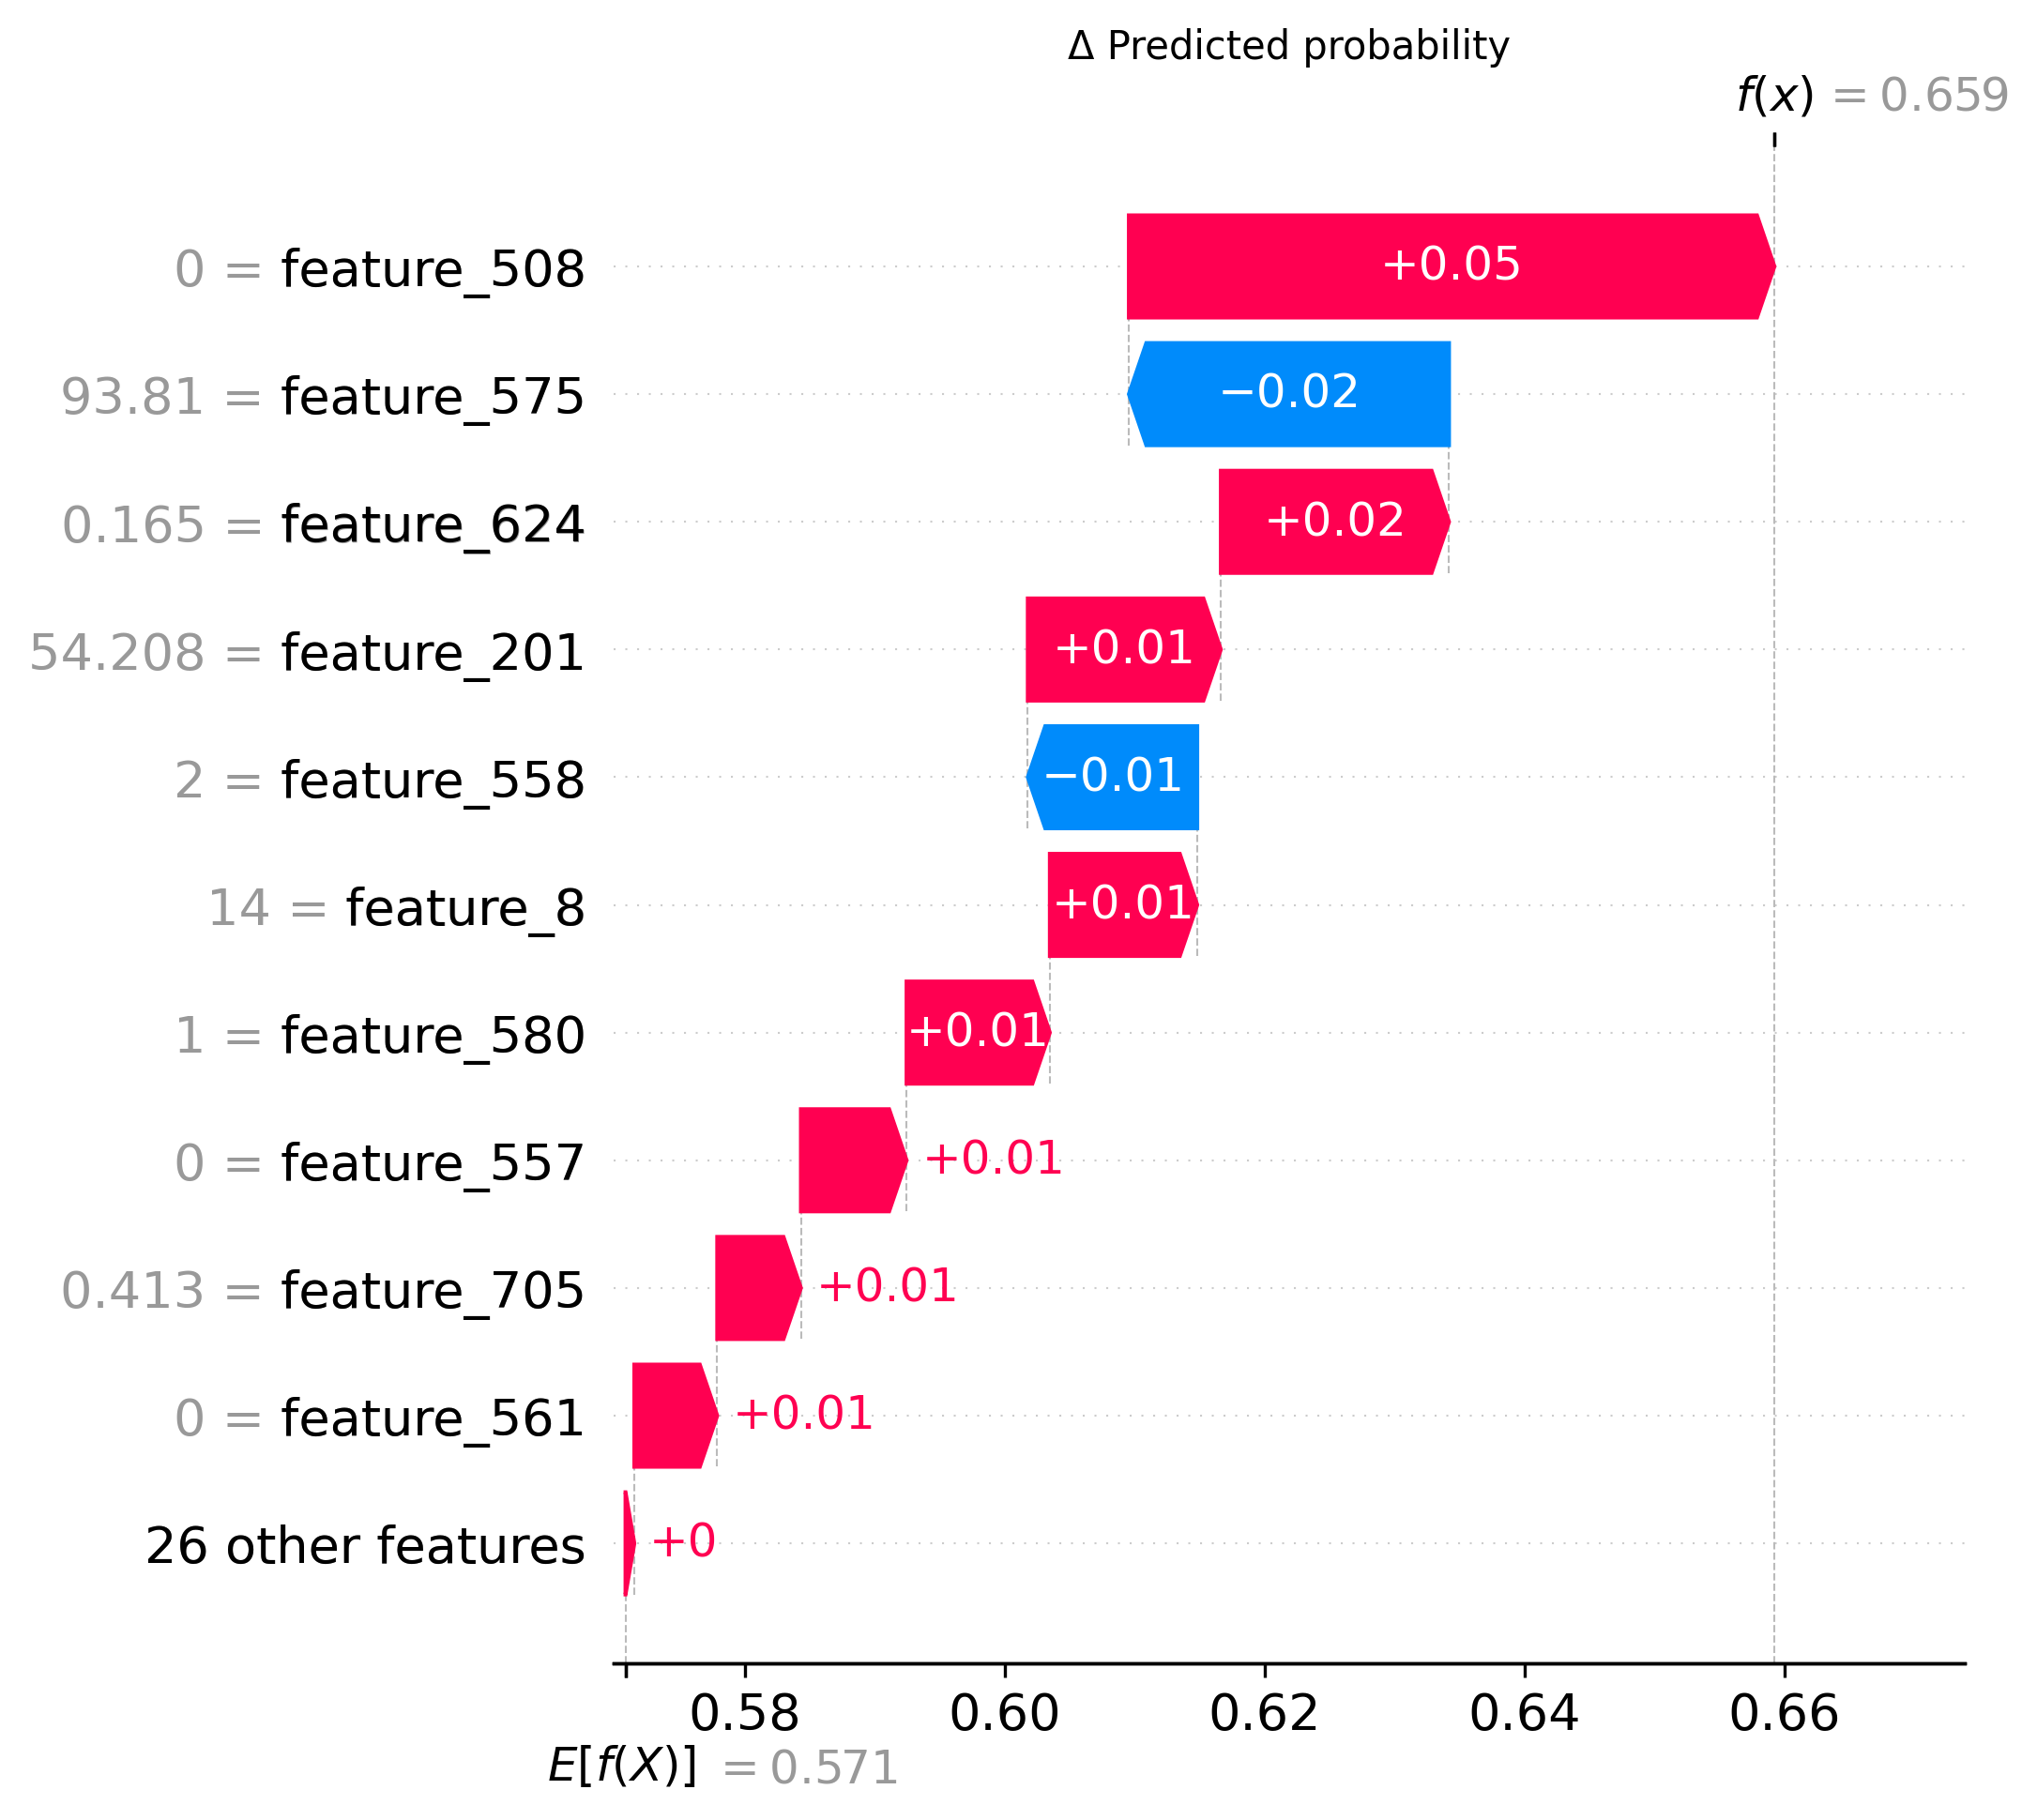

In [ ]:
#@title SHAP analysis
# ==================== SHAP Interpretability Analysis ====================
# Minor layout adjustment for better PDF display
!sed -i 's/plt.tight_layout()/plt.subplots_adjust(left=0.3)/' shoebill_shap_waterfall.py

# Create directory for SHAP analysis
!mkdir -p shap_plots

!python shoebill_shap_waterfall.py \
  --model shoebill_model \
  --input Example/TE_feature.csv \
  --train-data Example/TR_feature_3000.csv \
  --output-dir shap_plots \
  --max-display 11

print("\nSHAP plots saved in shap_plots/ folder")
print("Red = increases predicted probability, Blue = decreases")
print("\nA detailed description of all features and their computational definitions is ")
print("provided in 'https://github.com/KJ-Liao/Shoebill/tree/main/Supplementary_Files'.")

# SHAP analysis display
pdf_folder = "shap_plots"
png_files = sorted(glob.glob(f"{pdf_folder}/*.png"))

for png_path in png_files:
    display(Image(filename=png_path, width=700))